# 03 練習問題 解答 — 翻訳段とノイズ伝播
対象: [`notebooks/03_translation_readout.ipynb`](../notebooks/03_translation_readout.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
M, S, P = (Species(x) for x in ['m','s','P'])
A_M, B_M, B_S, K = 10.0, 1.0, 1.0, 100.0
def R(a,b,k): return ReactionRule(a,b,k)
def build(a_s, b_p=0.5, k_p=5.0):
    mdl = NetworkModel()
    for r in [R([],[M],A_M), R([],[S],a_s), R([M],[],B_M), R([S],[],B_S), R([M,S],[],K),
              R([M],[M,P],k_p), R([P],[],b_p)]:
        mdl.add_reaction_rule(r)
    return mdl
def stats(a_s, b_p=0.5, k_p=5.0):
    r = run_simulation(600.0, y0={}, model=build(a_s,b_p,k_p), solver='gillespie', ndiv=6000, species_list=['m','s','P'], rndseed=0)
    t = r.as_array()[1500:]; m, P_ = t[:,1], t[:,3]
    f = lambda x: (x.std()/x.mean() if x.mean()>0.3 else np.nan, x.var()/x.mean() if x.mean()>0.3 else np.nan)
    return f(m), f(P_)

## Q1. $b_p>b_m$（P が短寿命）にするとフィルタ効果は弱まる?

In [2]:
print(f"{'b_p':>5}{'CV_m':>8}{'CV_P':>8}{'CV_P/CV_m':>12}")
for b_p in [0.5, 1.0, 2.0]:
    (cm,_),(cp,_) = stats(8.0, b_p=b_p)
    print(f'{b_p:5.1f}{cm:8.2f}{cp:8.2f}{cp/cm:12.2f}')

  b_p    CV_m    CV_P   CV_P/CV_m
  0.5    1.05    0.61        0.58
  1.0    0.98    0.71        0.72
  2.0    0.94    0.85        0.90


**答**: $b_p$ を上げる（P を短寿命化）と $CV_P/CV_m$ が 1 に近づく＝**低域通過フィルタが弱まる**。P が短命だと mRNA のゆらぎを時間平均できず、そのまま追随してしまう。フィルタ効果は「P が mRNA より長寿命」であることに由来する。

## Q2. 翻訳 $k_p$ を上げると（バースト性↑）$CV_P$ は?

In [3]:
print(f"{'k_p':>5}{'<P>':>8}{'CV_P':>8}{'Fano_P':>9}")
for k_p in [2.0, 5.0, 20.0]:
    r = run_simulation(600.0, y0={}, model=build(8.0,0.5,k_p), solver='gillespie', ndiv=6000, species_list=['m','s','P'], rndseed=0)
    P_ = r.as_array()[1500:,3]
    print(f'{k_p:5.1f}{P_.mean():8.0f}{P_.std()/P_.mean():8.2f}{P_.var()/P_.mean():9.1f}')

  k_p     <P>    CV_P   Fano_P
  2.0      11    0.60      3.8
  5.0      24    0.61      8.7


 20.0     110    0.56     34.9


**答**: $k_p$ を上げると平均 $\langle P\rangle$ は上がり **CV_P はむしろ下がる**（分子数が増えて相対ノイズ減）。だが **Fano factor（var/mean）は上がる**——1 個の mRNA から多数の P が一気に作られる「翻訳バースト」が効くため。CV と Fano で違う側面が見える好例。

## Q3. Fano factor でも P を評価し、CV とどちらが解釈しやすいか

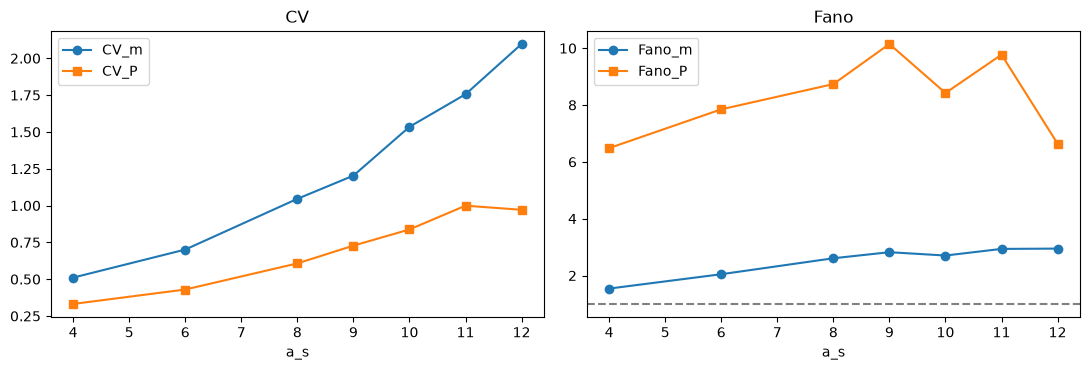

In [4]:
a_grid = [4,6,8,9,10,11,12]
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(11,3.8))
cvm=[]; cvp=[]; fam=[]; fap=[]
for a in a_grid:
    (cm,fm),(cp,fp) = stats(float(a)); cvm.append(cm); cvp.append(cp); fam.append(fm); fap.append(fp)
ax1.plot(a_grid, cvm,'o-',label='CV_m'); ax1.plot(a_grid, cvp,'s-',label='CV_P'); ax1.set_title('CV'); ax1.legend(); ax1.set_xlabel('a_s')
ax2.plot(a_grid, fam,'o-',label='Fano_m'); ax2.plot(a_grid, fap,'s-',label='Fano_P'); ax2.axhline(1,ls='--',c='gray'); ax2.set_title('Fano'); ax2.legend(); ax2.set_xlabel('a_s')
plt.tight_layout(); plt.show()

**答**: **CV** は「相対的なばらつきの大きさ」を直感的に示し、mRNA→P の平滑化（$CV_P<CV_m$）を読むのに向く。**Fano** は Poisson（=1）からの逸脱＝「増幅されているか」を示し、翻訳バーストのように平均が増えても超過ノイズが残る現象を捉える。**目的次第**——平滑化を語るなら CV、機構（バースト/増幅）を語るなら Fano が解釈しやすい。